# Notebook 03 — Retrain with New Features
New features vs Notebook01:
- H2H last 5 matches
- Recent form last 5 matches (separate from last 20)
- Competition importance (1–4)
- Home win rate vs Away win rate separately
- FIFA ranking

In [ ]:
# ============================================================
# CELL 1 — Load Data
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

results      = pd.read_csv('../../data/results.csv')
goalscorers  = pd.read_csv('../../data/goalscorers.csv')
shootouts    = pd.read_csv('../../data/shootouts.csv')
former_names = pd.read_csv('../../data/former_names.csv')
rankings     = pd.read_csv('../../dataII/rankings.csv')  # latest FIFA ranking

results['date']      = pd.to_datetime(results['date'])
goalscorers['date']  = pd.to_datetime(goalscorers['date'])
shootouts['date']    = pd.to_datetime(shootouts['date'])

print('Loaded!')
print('results     :', results.shape)
print('shootouts   :', shootouts.shape)
print('rankings    :', rankings.shape)

Loaded!
results     : (49477, 9)
shootouts   : (678, 5)
rankings    : (216, 4)


In [2]:
# ============================================================
# CELL 2 — Normalize Country Names
# ============================================================
name_map = dict(zip(former_names['former'], former_names['current']))

def normalize(name):
    return name_map.get(name, name)

results['home_team']     = results['home_team'].apply(normalize)
results['away_team']     = results['away_team'].apply(normalize)
goalscorers['home_team'] = goalscorers['home_team'].apply(normalize)
goalscorers['away_team'] = goalscorers['away_team'].apply(normalize)
goalscorers['team']      = goalscorers['team'].apply(normalize)
shootouts['home_team']   = shootouts['home_team'].apply(normalize)
shootouts['away_team']   = shootouts['away_team'].apply(normalize)
shootouts['winner']      = shootouts['winner'].apply(normalize)

print('Country names normalized!')

Country names normalized!


In [3]:
# ============================================================
# CELL 3 — Build ranking lookup dict  { team_name: rank }
# Use a large default rank (200) for teams not in the ranking list
# ============================================================
rank_lookup   = dict(zip(rankings['team'], rankings['fifa_rank']))
points_lookup = dict(zip(rankings['team'], rankings['fifa_points']))

def get_rank(team):
    return rank_lookup.get(team, 200)   # 200 = unknown / very low ranked

print('Ranking lookup ready — sample:')
for t in ['Brazil', 'France', 'Cambodia', 'Argentina']:
    print(f'  {t}: {get_rank(t)}')

Ranking lookup ready — sample:
  Brazil: 4.0
  France: 2.0
  Cambodia: 180.0
  Argentina: 1.0


In [4]:
# ============================================================
# CELL 4 — Drop rows with missing scores & create target label
# 0 = home win, 1 = draw, 2 = away win
# ============================================================
results = results.dropna(subset=['home_score', 'away_score']).copy()

def get_outcome(row):
    if row['home_score'] > row['away_score']:  return 0
    elif row['home_score'] == row['away_score']: return 1
    else: return 2

results['label'] = results.apply(get_outcome, axis=1)
results_sorted   = results.sort_values('date').reset_index(drop=True)

print(results['label'].value_counts())
print('0=home win  1=draw  2=away win')

label
0    24235
2    13967
1    11246
Name: count, dtype: int64
0=home win  1=draw  2=away win


In [5]:
# ============================================================
# CELL 5 — Helper Functions (all features)
# ============================================================

# --- Overall team stats (last n matches) ---
def team_stats(team, before_date, n=20):
    past = results_sorted[
        (results_sorted['date'] < before_date) &
        ((results_sorted['home_team'] == team) | (results_sorted['away_team'] == team))
    ].tail(n)
    if len(past) == 0:
        return {'win_rate': 0.5, 'avg_scored': 1.0, 'avg_conceded': 1.0, 'n_matches': 0}
    wins, scored, conceded = [], [], []
    for _, m in past.iterrows():
        if m['home_team'] == team:
            wins.append(1 if m['home_score'] > m['away_score'] else 0)
            scored.append(m['home_score']); conceded.append(m['away_score'])
        else:
            wins.append(1 if m['away_score'] > m['home_score'] else 0)
            scored.append(m['away_score']); conceded.append(m['home_score'])
    return {'win_rate': np.mean(wins), 'avg_scored': np.mean(scored),
            'avg_conceded': np.mean(conceded), 'n_matches': len(past)}

# --- Home win rate vs Away win rate separately (last n matches) ---
def team_stats_split(team, before_date, n=20):
    past_home = results_sorted[
        (results_sorted['date'] < before_date) &
        (results_sorted['home_team'] == team)
    ].tail(n)
    past_away = results_sorted[
        (results_sorted['date'] < before_date) &
        (results_sorted['away_team'] == team)
    ].tail(n)
    home_wr = (past_home['home_score'] > past_home['away_score']).mean() if len(past_home) > 0 else 0.5
    away_wr = (past_away['away_score'] > past_away['home_score']).mean() if len(past_away) > 0 else 0.5
    return float(home_wr), float(away_wr)

# --- Recent form: last 5 matches ---
def recent_form(team, before_date, n=5):
    s = team_stats(team, before_date, n=n)
    return s['win_rate'], s['avg_scored'], s['avg_conceded']

# --- H2H: last 5 matches between the two teams ---
def h2h_stats(home_team, away_team, before_date, n=5):
    past = results_sorted[
        (results_sorted['date'] < before_date) &
        (
            ((results_sorted['home_team'] == home_team) & (results_sorted['away_team'] == away_team)) |
            ((results_sorted['home_team'] == away_team) & (results_sorted['away_team'] == home_team))
        )
    ].tail(n)
    if len(past) == 0:
        return {'h2h_home_win_rate': 0.5, 'h2h_avg_home_scored': 1.0, 'h2h_avg_away_scored': 1.0, 'h2h_n': 0}
    home_wins, home_scored, away_scored = [], [], []
    for _, m in past.iterrows():
        if m['home_team'] == home_team:
            home_wins.append(1 if m['home_score'] > m['away_score'] else 0)
            home_scored.append(m['home_score']); away_scored.append(m['away_score'])
        else:
            home_wins.append(1 if m['away_score'] > m['home_score'] else 0)
            home_scored.append(m['away_score']); away_scored.append(m['home_score'])
    return {
        'h2h_home_win_rate':    np.mean(home_wins),
        'h2h_avg_home_scored':  np.mean(home_scored),
        'h2h_avg_away_scored':  np.mean(away_scored),
        'h2h_n':                len(past)
    }

# --- Competition importance (1=friendly, 2=qualifier, 3=continental, 4=World Cup) ---
def comp_importance(tournament):
    t = str(tournament).lower()
    if 'fifa world cup' in t:                                              return 4
    if any(x in t for x in ['euro', 'copa america', 'asian cup',
                              'africa cup', 'gold cup', 'nations cup']):   return 3
    if any(x in t for x in ['qualifier', 'qualification']):               return 2
    return 1  # friendly / other

# --- Shootout win rate ---
def shootout_win_rate(team, before_date):
    past = shootouts[
        (shootouts['date'] < before_date) &
        ((shootouts['home_team'] == team) | (shootouts['away_team'] == team))
    ]
    if len(past) == 0: return 0.5
    return (past['winner'] == team).sum() / len(past)

print('All helper functions defined!')

All helper functions defined!


In [ ]:
# ============================================================
# CELL 6 — Build Feature Table  (takes a few minutes)
# ============================================================
df = results_sorted[results_sorted['date'].dt.year >= 2000].copy().reset_index(drop=True)

def build_row(home, away, date, is_neutral, tournament, label, home_score, away_score):
    h            = team_stats(home, date)
    a            = team_stats(away, date)
    h_hw, h_aw   = team_stats_split(home, date)
    a_hw, a_aw   = team_stats_split(away, date)
    _, h_fsc, h_fcc = recent_form(home, date)
    _, a_fsc, a_fcc = recent_form(away, date)
    h2h          = h2h_stats(home, away, date)
    home_rank    = get_rank(home)
    away_rank    = get_rank(away)
    return {
        'date':                   date,
        'home_team':              home,
        'away_team':              away,
        'is_neutral':             is_neutral,
        'year':                   date.year,
        'comp_importance':        comp_importance(tournament),
        'home_win_rate':          h['win_rate'],
        'home_avg_scored':        h['avg_scored'],
        'home_avg_conceded':      h['avg_conceded'],
        'home_home_win_rate':     h_hw,
        'home_away_win_rate':     h_aw,
        'home_form_avg_scored':   h_fsc,
        'home_form_avg_conceded': h_fcc,
        'away_win_rate':          a['win_rate'],
        'away_avg_scored':        a['avg_scored'],
        'away_avg_conceded':      a['avg_conceded'],
        'away_home_win_rate':     a_hw,
        'away_away_win_rate':     a_aw,
        'away_form_avg_scored':   a_fsc,
        'away_form_avg_conceded': a_fcc,
        'h2h_home_win_rate':      h2h['h2h_home_win_rate'],
        'h2h_avg_home_scored':    h2h['h2h_avg_home_scored'],
        'h2h_avg_away_scored':    h2h['h2h_avg_away_scored'],
        'h2h_n':                  h2h['h2h_n'],
        'home_fifa_rank':         home_rank,
        'away_fifa_rank':         away_rank,
        'rank_diff':              away_rank - home_rank,
        'label':                  label,
        'home_score':             home_score,
        'away_score':             away_score,
    }

FLIP_LABEL = {0: 2, 1: 1, 2: 0}

rows = []
for i, row in df.iterrows():
    if i % 500 == 0:
        print(f'Processing {i}/{len(df)}...')

    home       = row['home_team']
    away       = row['away_team']
    date       = row['date']
    is_neutral = int(row['neutral'])
    tournament = row['tournament']
    label      = row['label']
    hs         = row['home_score']
    as_        = row['away_score']

    rows.append(build_row(home, away, date, is_neutral, tournament, label, hs, as_))

    if is_neutral:
        rows.append(build_row(away, home, date, is_neutral, tournament, FLIP_LABEL[label], as_, hs))

feat = pd.DataFrame(rows)
feat.to_csv('../../dataII/V2/features_v2.csv', index=False)
print('Done! Shape:', feat.shape)
feat.head()


In [7]:
# ============================================================
# CELL 7 — Train / Test Split
# ============================================================
from sklearn.model_selection import train_test_split

FEATURES = [
    'is_neutral', 'year', 'comp_importance',
    'home_win_rate', 'home_avg_scored', 'home_avg_conceded',
    'home_home_win_rate', 'home_away_win_rate',
    'home_form_avg_scored', 'home_form_avg_conceded',
    'away_win_rate', 'away_avg_scored', 'away_avg_conceded',
    'away_home_win_rate', 'away_away_win_rate',
    'away_form_avg_scored', 'away_form_avg_conceded',
    'h2h_home_win_rate', 'h2h_avg_home_scored', 'h2h_avg_away_scored', 'h2h_n',
    'home_fifa_rank', 'away_fifa_rank', 'rank_diff',
]

X = feat[FEATURES]
y = feat['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (26123, 24)
Test size : (6531, 24)


Random Forest       : 57.42%  (2.1s)
Gradient Boost      : 57.66%  (27.0s)


c:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Reg        : 56.88%  (2.9s)
XGBoost             : 55.80%  (1.1s)

Best outcome model: Gradient Boost  (57.66%)


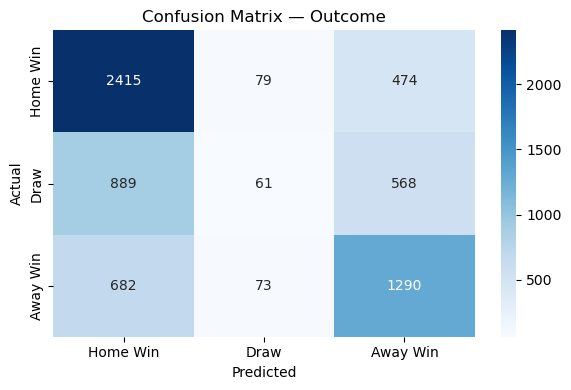

              precision    recall  f1-score   support

    Home Win       0.61      0.81      0.69      2968
        Draw       0.29      0.04      0.07      1518
    Away Win       0.55      0.63      0.59      2045

    accuracy                           0.58      6531
   macro avg       0.48      0.49      0.45      6531
weighted avg       0.52      0.58      0.52      6531



In [8]:
# ============================================================
# CELL 8 — Task 1: Train & Compare Classifiers (Outcome)
# ============================================================
import time
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

classifiers = {
    'Random Forest':  RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boost': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'Logistic Reg':   LogisticRegression(max_iter=1000, random_state=42),
}
if HAS_XGB:
    classifiers['XGBoost'] = XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss', verbosity=0)

clf_results = {}
for name, clf in classifiers.items():
    start = time.time()
    clf.fit(X_train, y_train)
    elapsed = time.time() - start
    acc = accuracy_score(y_test, clf.predict(X_test))
    clf_results[name] = {'model': clf, 'accuracy': acc}
    print(f'{name:20s}: {acc*100:.2f}%  ({elapsed:.1f}s)')

best_clf_name = max(clf_results, key=lambda k: clf_results[k]['accuracy'])
best_clf      = clf_results[best_clf_name]['model']
print(f'\nBest outcome model: {best_clf_name}  ({clf_results[best_clf_name]["accuracy"]*100:.2f}%)')

# Confusion matrix
y_pred = best_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Home Win','Draw','Away Win'],
            yticklabels=['Home Win','Draw','Away Win'], cmap='Blues')
plt.title('Confusion Matrix — Outcome'); plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=['Home Win','Draw','Away Win']))

In [9]:
# ============================================================
# CELL 9 — Task 2: Train & Compare Regressors (Exact Score)
# ============================================================
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error

try:
    from xgboost import XGBRegressor
    HAS_XGB_R = True
except ImportError:
    HAS_XGB_R = False

# Scores are already stored in feat (including swapped scores for mirrored rows),
# so no merge needed — the old merge would leave NaN for augmented neutral rows.
X_reg  = feat[FEATURES]
y_home = feat['home_score']
y_away = feat['away_score']

idx_train, idx_test = train_test_split(range(len(X_reg)), test_size=0.2, random_state=42)
X_train_r    = X_reg.iloc[idx_train].reset_index(drop=True)
X_test_r     = X_reg.iloc[idx_test].reset_index(drop=True)
y_home_train = y_home.iloc[idx_train].reset_index(drop=True)
y_home_test  = y_home.iloc[idx_test].reset_index(drop=True)
y_away_train = y_away.iloc[idx_train].reset_index(drop=True)
y_away_test  = y_away.iloc[idx_test].reset_index(drop=True)

regressors = {
    'Random Forest':  RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boost': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'Ridge':          Ridge(),
}
if HAS_XGB_R:
    regressors['XGBoost'] = XGBRegressor(n_estimators=200, random_state=42, verbosity=0)

reg_results = {}
for name, base in regressors.items():
    reg_home = clone(base); reg_away = clone(base)
    reg_home.fit(X_train_r, y_home_train)
    reg_away.fit(X_train_r, y_away_train)
    home_pred = reg_home.predict(X_test_r)
    away_pred = reg_away.predict(X_test_r)
    mae_home  = mean_absolute_error(y_home_test, home_pred)
    mae_away  = mean_absolute_error(y_away_test, away_pred)
    exact_acc = np.mean(
        (np.round(home_pred) == y_home_test.values) &
        (np.round(away_pred) == y_away_test.values)
    )
    reg_results[name] = {'home_model': reg_home, 'away_model': reg_away,
                         'mae_home': mae_home, 'mae_away': mae_away, 'exact_acc': exact_acc}
    print(f'{name:20s}  MAE home={mae_home:.2f}  away={mae_away:.2f}  exact score={exact_acc*100:.1f}%')

best_reg_name = max(reg_results, key=lambda k: reg_results[k]['exact_acc'])
best_reg      = reg_results[best_reg_name]
print(f'\nBest score model: {best_reg_name}  (exact acc = {best_reg["exact_acc"]*100:.1f}%)')

Random Forest         MAE home=1.04  away=0.90  exact score=10.0%
Gradient Boost        MAE home=1.03  away=0.88  exact score=10.6%
Ridge                 MAE home=1.05  away=0.90  exact score=10.9%
XGBoost               MAE home=1.07  away=0.92  exact score=10.4%

Best score model: Ridge  (exact acc = 10.9%)


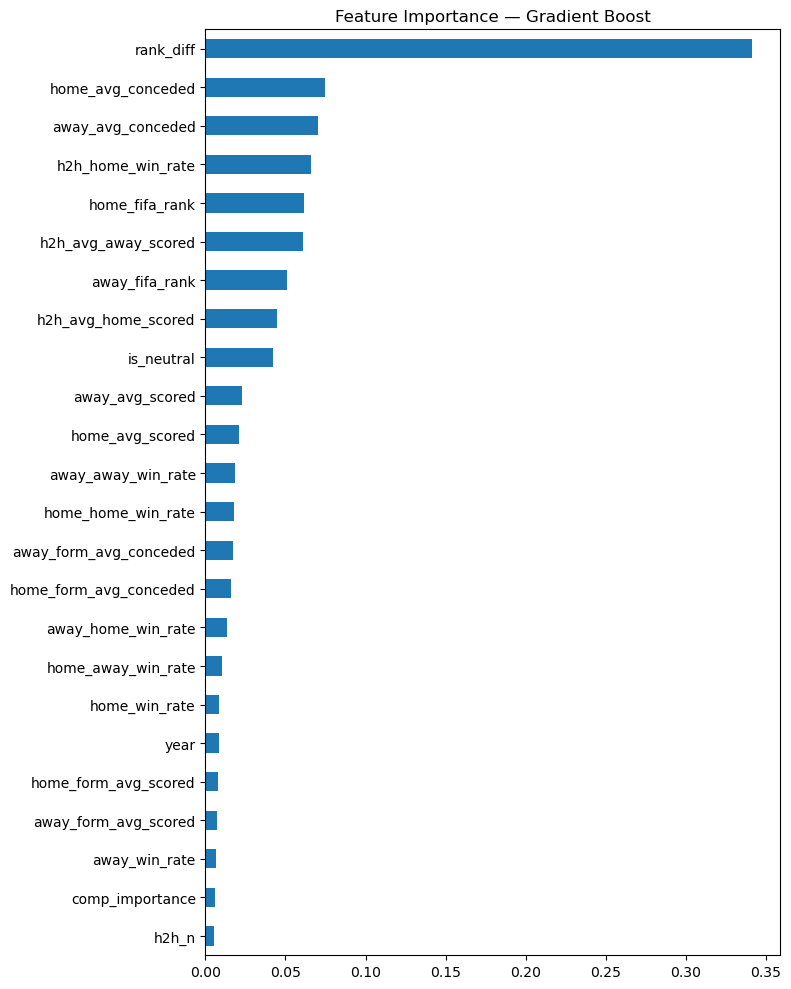

In [10]:
# ============================================================
# CELL 10 — Feature Importance
# ============================================================
if hasattr(best_clf, 'feature_importances_'):
    imp = pd.Series(best_clf.feature_importances_, index=FEATURES).sort_values()
    imp.plot(kind='barh', figsize=(8, 10), title=f'Feature Importance — {best_clf_name}')
    plt.tight_layout(); plt.show()

In [ ]:
# ============================================================
# CELL 11 — Save Models (v2)
# ============================================================
import joblib, os

os.makedirs('../../dataII/V2', exist_ok=True)
joblib.dump(best_clf,               '../../dataII/V2/model_outcome_v2.pkl')
joblib.dump(best_reg['home_model'], '../../dataII/V2/model_home_score_v2.pkl')
joblib.dump(best_reg['away_model'], '../../dataII/V2/model_away_score_v2.pkl')

print('Saved:')
print(f'  model_outcome_v2.pkl    — {best_clf_name}')
print(f'  model_home_score_v2.pkl — {best_reg_name}')
print(f'  model_away_score_v2.pkl — {best_reg_name}')


In [12]:
# ============================================================
# CELL 12 — Predict Function (updated with new features)
# ============================================================
def predict_match(home_team, away_team, is_neutral=0, tournament='Friendly'):
    today = pd.Timestamp.today()

    h           = team_stats(home_team, today)
    a           = team_stats(away_team, today)
    h_hw, h_aw  = team_stats_split(home_team, today)
    a_hw, a_aw  = team_stats_split(away_team, today)
    _, h_fsc, h_fcc = recent_form(home_team, today)
    _, a_fsc, a_fcc = recent_form(away_team, today)
    h2h         = h2h_stats(home_team, away_team, today)
    home_rank   = get_rank(home_team)
    away_rank   = get_rank(away_team)

    row = pd.DataFrame([{
        'is_neutral':             is_neutral,
        'year':                   today.year,
        'comp_importance':        comp_importance(tournament),
        'home_win_rate':          h['win_rate'],
        'home_avg_scored':        h['avg_scored'],
        'home_avg_conceded':      h['avg_conceded'],
        'home_home_win_rate':     h_hw,
        'home_away_win_rate':     h_aw,
        'home_form_avg_scored':   h_fsc,
        'home_form_avg_conceded': h_fcc,
        'away_win_rate':          a['win_rate'],
        'away_avg_scored':        a['avg_scored'],
        'away_avg_conceded':      a['avg_conceded'],
        'away_home_win_rate':     a_hw,
        'away_away_win_rate':     a_aw,
        'away_form_avg_scored':   a_fsc,
        'away_form_avg_conceded': a_fcc,
        'h2h_home_win_rate':      h2h['h2h_home_win_rate'],
        'h2h_avg_home_scored':    h2h['h2h_avg_home_scored'],
        'h2h_avg_away_scored':    h2h['h2h_avg_away_scored'],
        'h2h_n':                  h2h['h2h_n'],
        'home_fifa_rank':         home_rank,
        'away_fifa_rank':         away_rank,
        'rank_diff':              away_rank - home_rank,
    }])

    outcome   = best_clf.predict(row)[0]
    proba     = best_clf.predict_proba(row)[0]
    home_g    = max(0, int(round(best_reg['home_model'].predict(row)[0])))
    away_g    = max(0, int(round(best_reg['away_model'].predict(row)[0])))
    label     = {0: 'Home Win', 1: 'Draw', 2: 'Away Win'}

    print(f'\n  {home_team}  vs  {away_team}')
    print(f'  Tournament     : {tournament}  (importance={comp_importance(tournament)})')
    print(f'  Venue          : {"Neutral" if is_neutral else home_team + " home ground"}')
    print(f'  FIFA Ranks     : {home_team} #{home_rank}  vs  {away_team} #{away_rank}')
    print(f'  Predicted Score: {home_team} {home_g} - {away_g} {away_team}')
    print(f'  Outcome        : {label[outcome]}')
    print(f'  {home_team} win  : {proba[0]*100:.1f}%')
    print(f'  Draw           : {proba[1]*100:.1f}%')
    print(f'  {away_team} win  : {proba[2]*100:.1f}%')

In [13]:
predict_match('Norway', 'Senegal', is_neutral=1, tournament='FIFA World Cup')
# predict_match('France', 'England',   is_neutral=1, tournament='FIFA World Cup')
# predict_match('USA',    'Germany',   is_neutral=0, tournament='FIFA World Cup')


  Norway  vs  Senegal
  Tournament     : FIFA World Cup  (importance=4)
  Venue          : Neutral
  FIFA Ranks     : Norway #46.0  vs  Senegal #18.0
  Predicted Score: Norway 2 - 2 Senegal
  Outcome        : Away Win
  Norway win  : 34.7%
  Draw           : 28.5%
  Senegal win  : 36.8%


In [14]:
predict_match('Paraguay', 'Australia', is_neutral=1, tournament='FIFA World Cup')


  Paraguay  vs  Australia
  Tournament     : FIFA World Cup  (importance=4)
  Venue          : Neutral
  FIFA Ranks     : Paraguay #58.0  vs  Australia #23.0
  Predicted Score: Paraguay 1 - 1 Australia
  Outcome        : Away Win
  Paraguay win  : 20.2%
  Draw           : 29.8%
  Australia win  : 50.0%
